In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator

Original Circuit (to be cut)
=
Let's suppose we want to run a circuit that puts 4 qubits into the 1/rt(2) (|0000> + |1111>) state

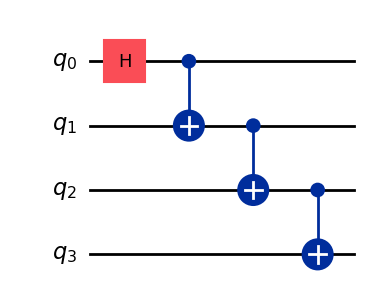

In [2]:
"""
First, let's look at the original circuit
"""

# Initialize the qubit and classical registers
qubits = QuantumRegister(5, "q")
outputs = ClassicalRegister(5, "c")
    
qc = QuantumCircuit(qubits, outputs)

# This circuit creates the 1/rt(2) (|0000> + |1111>) state
qc.h(qubits[0])
qc.cx(qubits[0], qubits[1])
qc.cx(qubits[1], qubits[2])
qc.cx(qubits[2], qubits[3])

qc.draw("mpl", idle_wires=False)


Suppose we only have access to a quantum processor with 3 qubits. We will need to cut this circuit into two partitions, each requiring 3 or less qubits.

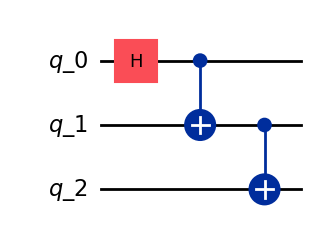

In [3]:
"""
Partition A will use qubits q0, q1, and q2, applying the first three operations of the full circuit
"""
q0 = QuantumRegister(1, "q_0")
q1 = QuantumRegister(1, "q_1")
q2 = QuantumRegister(1, "q_2")
c0 = ClassicalRegister(1, "c_0")
c1 = ClassicalRegister(1, "c_1")
c2 = ClassicalRegister(1, "c_2")

qc_A = QuantumCircuit(q0, q1, q2, c0, c1, c2)

qc_A.h(q0)
qc_A.cx(q0, q1)
qc_A.cx(q1, q2)  

qc_A.draw("mpl", idle_wires=False)


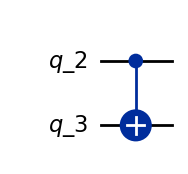

In [4]:
"""
Partition B will use qubits q2 and q3, applying the last CNOT operation from the full circuit
"""
# Initialize the qubit and classical registers
q2 = QuantumRegister(1, "q_2")
q3 = QuantumRegister(1, "q_3")
c2 = ClassicalRegister(1, "c_2")
c3 = ClassicalRegister(1, "c_3")
    
qc_B = QuantumCircuit(q2, q3, c2, c3)
    
qc_B.cx(q2, q3)

qc_B.draw("mpl", idle_wires=False)

We have our two partitions (QC_A and QC_B) that are small enough to run on a 3 qubit system, but we have a few steps to walk through to produce the output we would get from running the full circuit.

Step 1: Measurements with QC_A
=
Note that q2 is the only qubit needed in both partitions. We will run QC_A and measure q0 and q1 in the standard basis. For q2, we will need to measure in the X, Y, and Z bases separately.

For each possible measurement of q0q1 = 'a' in { 00, 01, 10, 11 }, we need:

    From Z Basis Measurement:
    rz[a] = (# times we measure '0' on q2) - (# times we measure '1' on q2) / (total # times we measure 'a' on q0q1 in M shots)

    From Y Basis Measurement:
    ry[a] = (# times we measure 'i' on q2) - (# times we measure '-i' on q2) / (total # times we measure 'a' on q0q1 in M shots)

    From X Basis Measurement:
    rx[a] = (# times we measure '+' on q2) - (# times we measure '-' on q2) / (total # times we measure 'a' on q0q1 in M shots)

    From All Cases:
    pA[a] = (# times we measure 'a' on q0q1 in N shots) / N

In [5]:
NUM_SHOTS = 4096

"""
Below is a function that will take the result from running QC_A and determine the above values
We will need to implement and run the circuit 3 times (one for each of the different bases) 
"""
def get_qc_A_probabilities(job_result, num_shots, basis):
    c_0_results = job_result[0].data['c_0'].array
    c_1_results = job_result[0].data['c_1'].array
    c_2_results = job_result[0].data['c_2'].array
    
    pA = {'00': 0, '01': 0, '10': 0, '11': 0}
    r = {'00': 0, '01': 0, '10': 0, '11': 0}
    rc = {'00': 0, '01': 0, '10': 0, '11': 0}
    
    def to_add(shot_result) -> int:
        return (0-2)*int(shot_result[0]) + 1 # if the result was 0, add one; if the result was 1, subtract 1
    
    for shot in range(num_shots):
        if c_0_results[shot] == 0 and c_1_results[shot] == 0:
            pA['00'] += 1
            r['00'] += to_add(c_2_results[shot])
            rc['00'] += 1
        
        if c_0_results[shot] == 0 and c_1_results[shot] == 1:
            pA['01'] += 1
            r['01'] += to_add(c_2_results[shot])
            rc['01'] += 1
        
        if c_0_results[shot] == 1 and c_1_results[shot] == 0:
            pA['10'] += 1
            r['10'] += to_add(c_2_results[shot])
            rc['10'] += 1
        
        if c_0_results[shot] == 1 and c_1_results[shot] == 1:
            pA['11'] += 1
            r['11'] += to_add(c_2_results[shot])
            rc['11'] += 1

    for a in pA.keys():
        print(f"{a} was the result {pA[a]} times in {num_shots} shots; pA[{a}] = {pA[a]/num_shots}")
        print(f"r{basis}[{a}] = {r[a]/num_shots}")
        pA[a] = pA[a]/num_shots
        if rc[a] != 0:
            r[a] = r[a]/rc[a]
    
    return pA, r

Z-basis (0/1) measurement of q2 in QC_A
=

In [6]:
# Initialize the qubit and classical registers
q0 = QuantumRegister(1, "q_0")
q1 = QuantumRegister(1, "q_1")
q2 = QuantumRegister(1, "q_2")
c0 = ClassicalRegister(1, "c_0")
c1 = ClassicalRegister(1, "c_1")
c2 = ClassicalRegister(1, "c_2")
    
qc_A = QuantumCircuit(q0, q1, q2, c0, c1, c2)
    
qc_A.h(q0)
qc_A.cx(q0, q1)
qc_A.cx(q1, q2)


In [7]:
# To measure q2 in the Z-basis, do nothing
qc_A.id(q2)

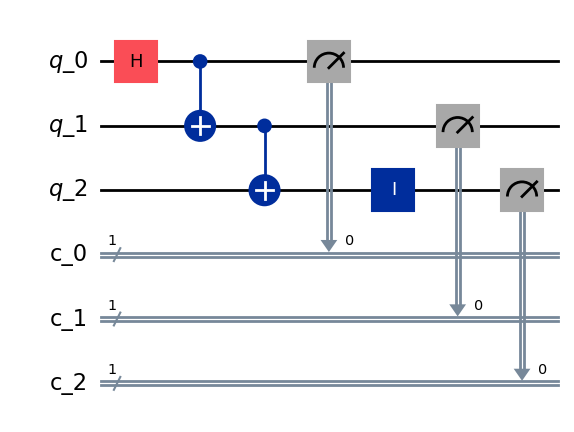

In [8]:
# Add measurements 
qc_A.measure(0,0)
qc_A.measure(1,1)
qc_A.measure(2,2)

# Display the circuit
qc_A.draw("mpl", idle_wires=False)

In [9]:
# Simulate the job and get the result counts
backend = AerSimulator(method="statevector")
sampler = Sampler(backend)
result = sampler.run([qc_A], shots=NUM_SHOTS).result()

pA_z, rz = get_qc_A_probabilities(result, NUM_SHOTS, 'z')

00 was the result 2057 times in 4096 shots; pA[00] = 0.502197265625
rz[00] = 0.502197265625
01 was the result 0 times in 4096 shots; pA[01] = 0.0
rz[01] = 0.0
10 was the result 0 times in 4096 shots; pA[10] = 0.0
rz[10] = 0.0
11 was the result 2039 times in 4096 shots; pA[11] = 0.497802734375
rz[11] = -0.497802734375


Y-basis (i/-i) measurement of q2 in QC_A
=

In [10]:
# Initialize the qubit and classical registers
q0 = QuantumRegister(1, "q_0")
q1 = QuantumRegister(1, "q_1")
q2 = QuantumRegister(1, "q_2")
c0 = ClassicalRegister(1, "c_0")
c1 = ClassicalRegister(1, "c_1")
c2 = ClassicalRegister(1, "c_2")
    
qc_A = QuantumCircuit(q0, q1, q2, c0, c1, c2)
    
qc_A.h(q0)
qc_A.cx(q0, q1)
qc_A.cx(q1, q2)


In [11]:
# To measure q2 in the Y-basis, apply inverse-S and then H
qc_A.sdg(2)
qc_A.h(2)

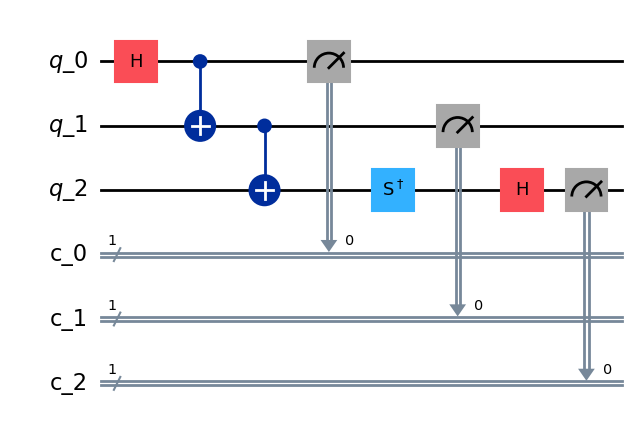

In [12]:
# Add measurements 
qc_A.measure(0,0)
qc_A.measure(1,1)
qc_A.measure(2,2)

# Display the circuit
qc_A.draw("mpl", idle_wires=False)

In [13]:
# Simulate the job and get the result counts
backend = AerSimulator(method="statevector")
sampler = Sampler(backend)
result = sampler.run([qc_A], shots=NUM_SHOTS).result()

# NOTE: the ry values should be near 0
pA_y, ry = get_qc_A_probabilities(result, NUM_SHOTS, 'y')

00 was the result 2066 times in 4096 shots; pA[00] = 0.50439453125
ry[00] = 0.0068359375
01 was the result 0 times in 4096 shots; pA[01] = 0.0
ry[01] = 0.0
10 was the result 0 times in 4096 shots; pA[10] = 0.0
ry[10] = 0.0
11 was the result 2030 times in 4096 shots; pA[11] = 0.49560546875
ry[11] = 0.00244140625


X-basis (+/-) measurement of q2 in QC_A
=

In [14]:
# Initialize the qubit and classical registers
q0 = QuantumRegister(1, "q_0")
q1 = QuantumRegister(1, "q_1")
q2 = QuantumRegister(1, "q_2")
c0 = ClassicalRegister(1, "c_0")
c1 = ClassicalRegister(1, "c_1")
c2 = ClassicalRegister(1, "c_2")
    
qc_A = QuantumCircuit(q0, q1, q2, c0, c1, c2)
    
qc_A.h(q0)
qc_A.cx(q0, q1)
qc_A.cx(q1, q2)

In [15]:
# Measure q2 in the X basis
qc_A.h(q2)

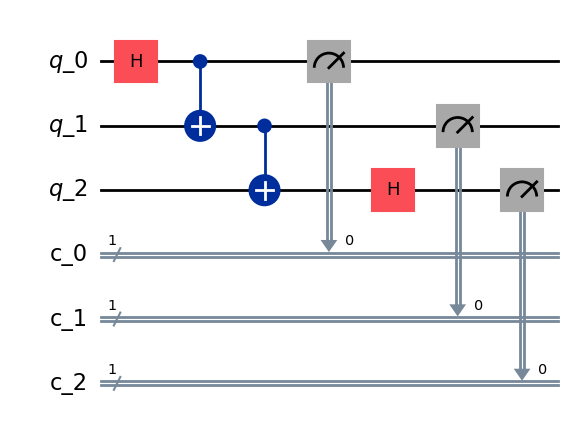

In [16]:
# Add measurements 
qc_A.measure(0,0)
qc_A.measure(1,1)
qc_A.measure(2,2)

# Display the circuit
qc_A.draw("mpl", idle_wires=False)

In [17]:
# Simulate the job and get the result counts
backend = AerSimulator(method="statevector")
sampler = Sampler(backend)
result = sampler.run([qc_A], shots=NUM_SHOTS).result()

# NOTE: the rx values should be near 0
pA_x, rx = get_qc_A_probabilities(result, NUM_SHOTS, 'x')

00 was the result 2002 times in 4096 shots; pA[00] = 0.48876953125
rx[00] = 0.01318359375
01 was the result 0 times in 4096 shots; pA[01] = 0.0
rx[01] = 0.0
10 was the result 0 times in 4096 shots; pA[10] = 0.0
rx[10] = 0.0
11 was the result 2094 times in 4096 shots; pA[11] = 0.51123046875
rx[11] = -0.0107421875


In [18]:
"""
As one last part to Step 1, we should combine the pA values into one

Note:
    q2 was measured in each of the 3 bases NUM_SHOTS times,
    so q0q1 were measured in the standard basis 3*NUM_SHOTS times
"""
pA = {
    '00': (pA_z['00'] + pA_y['00'] + pA_x['00']) / 3,
    '01': (pA_z['01'] + pA_y['01'] + pA_x['01']) / 3,
    '10': (pA_z['10'] + pA_y['10'] + pA_x['10']) / 3,
    '11': (pA_z['11'] + pA_y['11'] + pA_x['11']) / 3,
}

for binary in pA.keys():
    print(f"pA[{binary}] = {pA[binary]}")


pA[00] = 0.4984537760416667
pA[01] = 0.0
pA[10] = 0.0
pA[11] = 0.5015462239583334


Step 2: Measurements with QC_B
=
Note that q2 is the only qubit needed in both partitions. We will run QC_B and initialize q3 to 0. We will need to do measurements with q2 initialized to each of 'psi' in {|0>, |1>, |+>, |->, |i>, |-i>}

For each such initialization 'psi', and for each possible standard basis measurement of q2q3 = 'b' in { 00, 01, 10, 11 }, we need:
    
    pB[psi][b] = (# times we measure 'b' on q2q3 in N shots) / N, when q2 is initialized to 'psi'


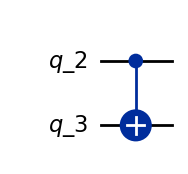

In [19]:
"""
Recall, this is what QC_B looks like
"""
# Initialize the qubit and classical registers
q2 = QuantumRegister(1, "q_2")
q3 = QuantumRegister(1, "q_3")
c2 = ClassicalRegister(1, "c_2")
c3 = ClassicalRegister(1, "c_3")
    
qc_B = QuantumCircuit(q2, q3, c2, c3)
    
qc_B.cx(q2, q3)

qc_B.draw("mpl", idle_wires=False)

In [20]:
"""
The function that accomplishes our task for Step 2 is similar to the one for Step 1, except we do not need to calculate the r values
"""
def get_qc_B_probabilities(job_result, num_shots, init):
    c_2_results = job_result[0].data['c_2'].array
    c_3_results = job_result[0].data['c_3'].array
    
    pB = {'00': 0, '01': 0, '10': 0, '11': 0}
    
    for shot in range(num_shots):
        if c_2_results[shot] == 0 and c_3_results[shot] == 0:
            pB['00'] += 1
        
        if c_2_results[shot] == 0 and c_3_results[shot] == 1:
            pB['01'] += 1
        
        if c_2_results[shot] == 1 and c_3_results[shot] == 0:
            pB['10'] += 1
        
        if c_2_results[shot] == 1 and c_3_results[shot] == 1:
            pB['11'] += 1
    
    for b in pB.keys():
        print(f"{b} was the result {pB[b]} times in {num_shots} shots when q2 was initialized to {init}; pB[{init}][{b}] = {pB[b]/num_shots}")
        pB[b] = pB[b]/num_shots
    
    return pB

In [21]:
"""
For convenience, we will also define some functions to help us set up the and run the circuit
"""
def initialize_QC_B() -> QuantumCircuit:
    # Initialize the qubit and classical registers
    q2 = QuantumRegister(1, "q_2")
    q3 = QuantumRegister(1, "q_3")
    c2 = ClassicalRegister(1, "c_2")
    c3 = ClassicalRegister(1, "c_3")
    
    qc = QuantumCircuit(q2, q3, c2, c3)

    return qc

def run_QC_B_test(qc, psi):
    # Do the rest of the circuit
    qc.cx(0, 1)
    
    # Add measurements 
    qc.measure(0,0)
    qc.measure(1,1)

    # Simulate the job and get the result counts
    backend = AerSimulator(method="statevector")
    
    sampler = Sampler(backend)
    result = sampler.run([qc], shots=NUM_SHOTS).result()
    
    return get_qc_B_probabilities(result, NUM_SHOTS, psi)

Initializing q2 to |0> in QC_B
=

In [22]:
# Initialize QC_B
qc_B = initialize_QC_B()

# Do nothing to initialize q2 in the |0> state
qc_B.id(0)

# Run the test to get the probabilities
pB_0 = run_QC_B_test(qc_B, '0')


00 was the result 4096 times in 4096 shots when q2 was initialized to 0; pB[0][00] = 1.0
01 was the result 0 times in 4096 shots when q2 was initialized to 0; pB[0][01] = 0.0
10 was the result 0 times in 4096 shots when q2 was initialized to 0; pB[0][10] = 0.0
11 was the result 0 times in 4096 shots when q2 was initialized to 0; pB[0][11] = 0.0


Initializing q2 to |1> in QC_B
=

In [23]:
# Initialize QC_B
qc_B = initialize_QC_B()

# Initialize q2 in the |1> state
qc_B.x(0)

# Run the test to get the probabilities
pB_1 = run_QC_B_test(qc_B, '1')


00 was the result 0 times in 4096 shots when q2 was initialized to 1; pB[1][00] = 0.0
01 was the result 0 times in 4096 shots when q2 was initialized to 1; pB[1][01] = 0.0
10 was the result 0 times in 4096 shots when q2 was initialized to 1; pB[1][10] = 0.0
11 was the result 4096 times in 4096 shots when q2 was initialized to 1; pB[1][11] = 1.0


Initializing q2 to |+> in QC_B
=

In [24]:
# Initialize QC_B
qc_B = initialize_QC_B()

# Initialize q2 in the |+> state
qc_B.h(0)

# Run the test to get the probabilities
pB_plus = run_QC_B_test(qc_B, '+')


00 was the result 2084 times in 4096 shots when q2 was initialized to +; pB[+][00] = 0.5087890625
01 was the result 0 times in 4096 shots when q2 was initialized to +; pB[+][01] = 0.0
10 was the result 0 times in 4096 shots when q2 was initialized to +; pB[+][10] = 0.0
11 was the result 2012 times in 4096 shots when q2 was initialized to +; pB[+][11] = 0.4912109375


Initializing q2 to |-> in QC_B
=

In [25]:
# Initialize QC_B
qc_B = initialize_QC_B()

# Initialize q2 in the |-> state
qc_B.h(0)
qc_B.x(0)

# Run the test to get the probabilities
pB_minus = run_QC_B_test(qc_B, '-')


00 was the result 1931 times in 4096 shots when q2 was initialized to -; pB[-][00] = 0.471435546875
01 was the result 0 times in 4096 shots when q2 was initialized to -; pB[-][01] = 0.0
10 was the result 0 times in 4096 shots when q2 was initialized to -; pB[-][10] = 0.0
11 was the result 2165 times in 4096 shots when q2 was initialized to -; pB[-][11] = 0.528564453125


Initializing q2 to |i> in QC_B
=

In [26]:
# Initialize QC_B
qc_B = initialize_QC_B()

# Initialize q2 in the |i> state
qc_B.h(0)
qc_B.s(0)

# Run the test to get the probabilities
pB_i = run_QC_B_test(qc_B, 'i')


00 was the result 2001 times in 4096 shots when q2 was initialized to i; pB[i][00] = 0.488525390625
01 was the result 0 times in 4096 shots when q2 was initialized to i; pB[i][01] = 0.0
10 was the result 0 times in 4096 shots when q2 was initialized to i; pB[i][10] = 0.0
11 was the result 2095 times in 4096 shots when q2 was initialized to i; pB[i][11] = 0.511474609375


Initializing q2 to |-i> in QC_B
=

In [27]:
# Initialize QC_B
qc_B = initialize_QC_B()

# Initialize q2 in the |i> state
qc_B.h(0)
qc_B.sdg(0)

# Run the test to get the probabilities
pB_mi = run_QC_B_test(qc_B, '-i')


00 was the result 2102 times in 4096 shots when q2 was initialized to -i; pB[-i][00] = 0.51318359375
01 was the result 0 times in 4096 shots when q2 was initialized to -i; pB[-i][01] = 0.0
10 was the result 0 times in 4096 shots when q2 was initialized to -i; pB[-i][10] = 0.0
11 was the result 1994 times in 4096 shots when q2 was initialized to -i; pB[-i][11] = 0.48681640625


Step 3
=
We can now derive the final probabilities that would be expected of running the full circuit.


In [28]:
"""
Given a binary string in {0,1}^4, get the probability of that being the output from the full circuit
"""
def get_p_final(binary: str):
    a = binary[:2]
    b = binary[2:]

    p_b_a = 0.5*(pB_0[b] + pB_1[b]) + \
            rx[a]*(pB_plus[b] - pB_minus[b]) + \
            ry[a]*(pB_i[b] - pB_mi[b]) + \
            0.5*rz[a]*(pB_0[b] - pB_1[b])
    
    return pA[a] * p_b_a

In [29]:
# We will store the values in a dictionary similar to before
p_final = dict()

n_bits = 4
for num in range(2**n_bits):
    binary = format(num, f'0{n_bits}b')
    p_final[binary] = get_p_final(binary)
    
for b in p_final.keys():
    print(f"Probability to Measure {b}: {p_final[b]}")

Probability to Measure 0000: 0.49878941024132306
Probability to Measure 0001: 0.0
Probability to Measure 0010: 0.0
Probability to Measure 0011: -0.0003356341996564171
Probability to Measure 0100: 0.0
Probability to Measure 0101: 0.0
Probability to Measure 0110: 0.0
Probability to Measure 0111: 0.0
Probability to Measure 1000: 0.0
Probability to Measure 1001: 0.0
Probability to Measure 1010: 0.0
Probability to Measure 1011: 0.0
Probability to Measure 1100: -0.00045457973343414565
Probability to Measure 1101: 0.0
Probability to Measure 1110: 0.0
Probability to Measure 1111: 0.5020008036917675


In [30]:
# We can validate that the sum of the probabilities is equal to 1

total = 0
for b in p_final.keys():
    total += p_final[b]
print(f"Sum of Probabilities: {total}")


Sum of Probabilities: 1.0
